In [25]:
import pandas as pd

# Load the dataset
df = pd.read_csv('salary-dataset.csv')

# Inspect data
print("--- Head ---")
print(df.head())
print("\n--- Info ---")
df.info()

--- Head ---
   Unnamed: 0  YearsExperience  Salary
0           0              1.2   39344
1           1              1.4   46206
2           2              1.6   37732
3           3              2.1   43526
4           4              2.3   39892

--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       36 non-null     int64  
 1   YearsExperience  36 non-null     float64
 2   Salary           36 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 996.0 bytes


In [27]:
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())

       Unnamed: 0  YearsExperience         Salary
count   36.000000        36.000000      36.000000
mean    17.500000         6.522222   85667.083333
std     10.535654         3.616637   33242.427357
min      0.000000         1.200000   37732.000000
25%      8.750000         3.675000   57051.000000
50%     17.500000         5.700000   82226.500000
75%     26.250000         9.625000  114602.250000
max     35.000000        13.000000  138821.000000

Missing values:
Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64


Linear Regression Metrics:
MAE: 5802.51
MSE: 39318711.54
RMSE: 6270.46

Polynomial Regression (Degree 2) Metrics:
MAE: 5435.01
MSE: 37704204.94
RMSE: 6140.37


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


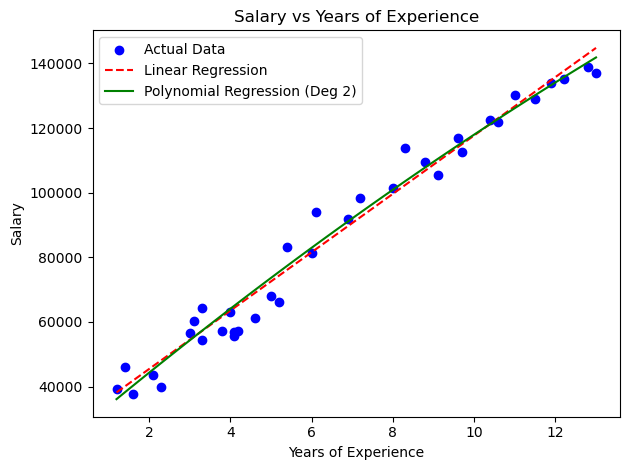

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load data
df = pd.read_csv('salary-dataset.csv')

# Preprocessing: drop Unnamed: 0 if it exists
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

X = df[['YearsExperience']]
y = df['Salary']

# Split data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

# --- Polynomial Regression (Degree 2) ---
poly_features = PolynomialFeatures(degree=2)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)

print("Linear Regression Metrics:")
print(f"MAE: {mae_lr:.2f}")
print(f"MSE: {mse_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")

print("\nPolynomial Regression (Degree 2) Metrics:")
print(f"MAE: {mae_poly:.2f}")
print(f"MSE: {mse_poly:.2f}")
print(f"RMSE: {rmse_poly:.2f}")

# Plotting
# To sort for smooth polynomial line
X_grid = np.linspace(X.min().values[0], X.max().values[0], 100).reshape(-1, 1)
y_grid_lr = lr_model.predict(X_grid)
y_grid_poly = poly_model.predict(poly_features.transform(X_grid))

plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X_grid, y_grid_lr, color='red', linestyle='--', label='Linear Regression')
plt.plot(X_grid, y_grid_poly, color='green', label='Polynomial Regression (Deg 2)')
plt.title('Salary vs Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.tight_layout()
plt.show('regression_comparison.png')
plt.close()

Polynomial Regression (Degree 3) Metrics:
MAE: 4295.13
MSE: 26546825.50
RMSE: 5152.36


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


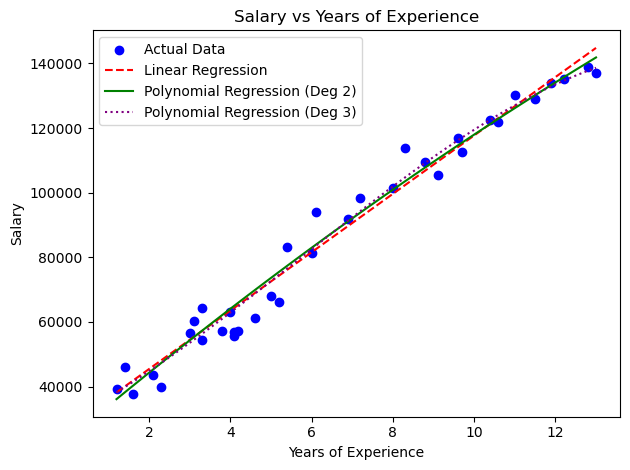

In [33]:
# --- Polynomial Regression (Degree 3) ---
poly_features_3 = PolynomialFeatures(degree=3)
X_train_poly3 = poly_features_3.fit_transform(X_train)
X_test_poly3 = poly_features_3.transform(X_test)

poly_model_3 = LinearRegression()
poly_model_3.fit(X_train_poly3, y_train)
y_pred_poly3 = poly_model_3.predict(X_test_poly3)

mae_poly3 = mean_absolute_error(y_test, y_pred_poly3)
mse_poly3 = mean_squared_error(y_test, y_pred_poly3)
rmse_poly3 = np.sqrt(mse_poly3)

print("Polynomial Regression (Degree 3) Metrics:")
print(f"MAE: {mae_poly3:.2f}")
print(f"MSE: {mse_poly3:.2f}")
print(f"RMSE: {rmse_poly3:.2f}")

# Let's save a plot with both degree 2 and degree 3 to check visual appearance
y_grid_poly3 = poly_model_3.predict(poly_features_3.transform(X_grid))

plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X_grid, y_grid_lr, color='red', linestyle='--', label='Linear Regression')
plt.plot(X_grid, y_grid_poly, color='green', label='Polynomial Regression (Deg 2)')
plt.plot(X_grid, y_grid_poly3, color='purple', linestyle=':', label='Polynomial Regression (Deg 3)')
plt.title('Salary vs Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.tight_layout()
plt.show('regression_comparison_v2.png')
plt.close()

Outliers detected in 'YearsExperience': 0
Outliers detected in 'Salary': 0

LINEAR REGRESSION METRICS:
Mean Absolute Error (MAE):     $5,802.51
Mean Squared Error (MSE):      39,318,711.54
Root Mean Squared Error (RMSE): $6,270.46

POLYNOMIAL REGRESSION (DEGREE 3) METRICS:
Mean Absolute Error (MAE):     $4,295.13
Mean Squared Error (MSE):      26,546,825.50
Root Mean Squared Error (RMSE): $5,152.36



/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


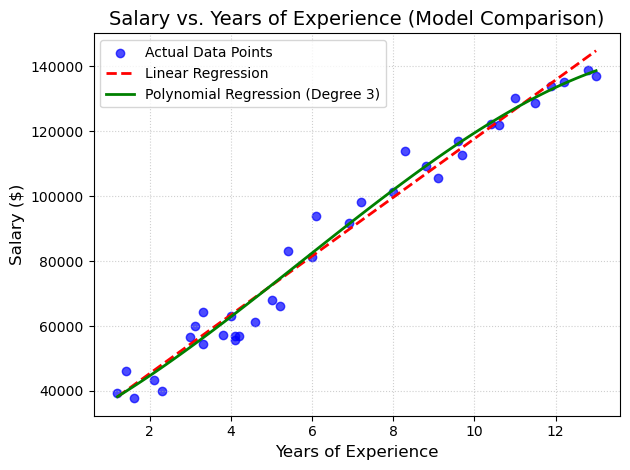

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Load the dataset
df = pd.read_csv('salary-dataset.csv')

# 2. Data Cleaning
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# 3. Outlier Detection using IQR Method
def check_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    print(f"Outliers detected in '{column}': {len(outliers)}")

check_outliers(df, 'YearsExperience')
check_outliers(df, 'Salary')

# 4. Preprocessing and Train-Test Split
X = df[['YearsExperience']]
y = df['Salary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# LINEAR REGRESSION MODEL
# ==========================================
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

# ==========================================
# POLYNOMIAL REGRESSION MODEL (Degree 3)
# ==========================================
poly_features = PolynomialFeatures(degree=3)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)

# Print Evaluation Metrics
print("\n" + "="*40)
print("LINEAR REGRESSION METRICS:")
print(f"Mean Absolute Error (MAE):     ${mae_lr:,.2f}")
print(f"Mean Squared Error (MSE):      {mse_lr:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse_lr:,.2f}")

print("\nPOLYNOMIAL REGRESSION (DEGREE 3) METRICS:")
print(f"Mean Absolute Error (MAE):     ${mae_poly:,.2f}")
print(f"Mean Squared Error (MSE):      {mse_poly:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse_poly:,.2f}")
print("="*40 + "\n")

# ==========================================
# VISUALIZATION
# ==========================================
# Generate a smooth line range for plotting curves
X_grid = np.linspace(X.min().values[0], X.max().values[0], 100).reshape(-1, 1)
y_grid_lr = lr_model.predict(X_grid)
y_grid_poly = poly_model.predict(poly_features.transform(X_grid))

plt.scatter(X, y, color='blue', alpha=0.7, label='Actual Data Points')
plt.plot(X_grid, y_grid_lr, color='red', linestyle='--', linewidth=2, label='Linear Regression')
plt.plot(X_grid, y_grid_poly, color='green', linewidth=2, label='Polynomial Regression (Degree 3)')

plt.title('Salary vs. Years of Experience (Model Comparison)', fontsize=14)
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Salary ($)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Save the plot image
plt.show('regression_comparison_plot.png')